In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Upload చేసి load చేయి
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.head()

Saving Sample - Superstore.csv to Sample - Superstore (2).csv


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:

df.info()
df.describe()
df.isnull().sum()


df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%b')
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

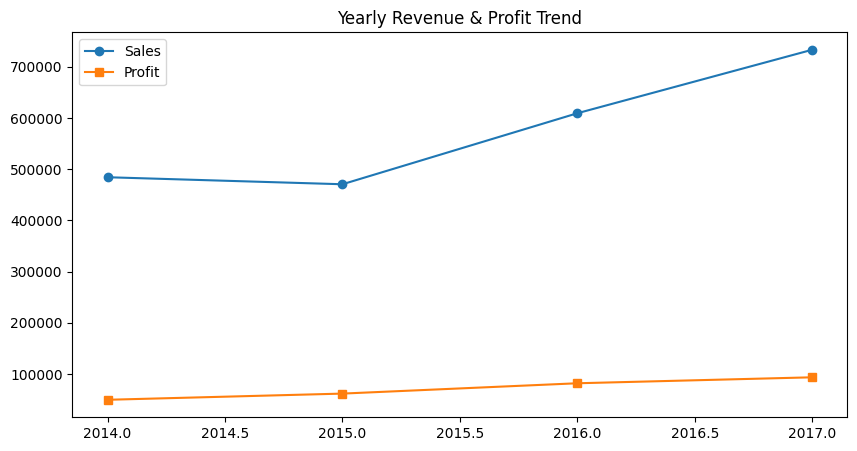

In [5]:
# Yearly Sales Trend
yearly_sales = df.groupby('Year')[['Sales','Profit']].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(yearly_sales['Year'], yearly_sales['Sales'], marker='o', label='Sales')
plt.plot(yearly_sales['Year'], yearly_sales['Profit'], marker='s', label='Profit')
plt.title('Yearly Revenue & Profit Trend')
plt.legend()
plt.savefig('yearly_trend.png')
plt.show()

In [6]:
# Category-wise Sales
cat_sales = df.groupby('Category')[['Sales','Profit']].sum().reset_index()

# Sub-Category Top 10
subcat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

# Top 10 Products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

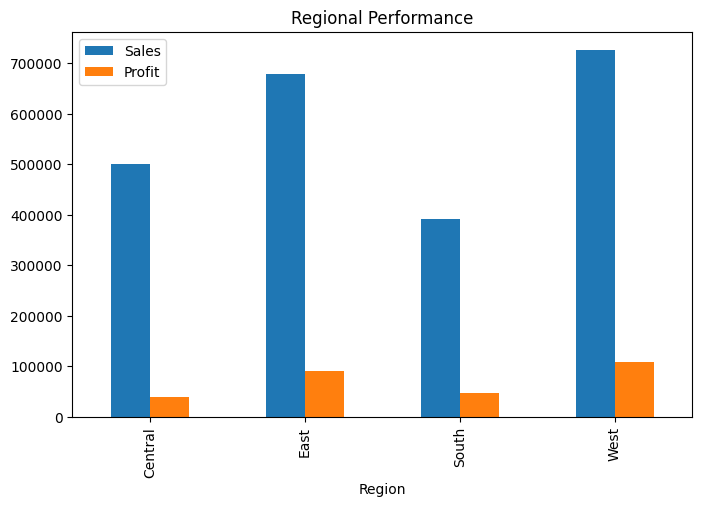

In [7]:
region_perf = df.groupby('Region')[['Sales','Profit']].sum().reset_index()

# Bar chart
region_perf.plot(x='Region', kind='bar', figsize=(8,5), title='Regional Performance')
plt.savefig('regional_perf.png')
plt.show()

In [8]:
print("=== KPI SUMMARY ===")
print(f"Total Revenue: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Profit Margin: {(df['Profit'].sum()/df['Sales'].sum()*100):.2f}%")
print(f"Total Orders: {df['Order ID'].nunique()}")
print(f"Total Customers: {df['Customer ID'].nunique()}")
print(f"Best Region: {df.groupby('Region')['Sales'].sum().idxmax()}")
print(f"Best Category: {df.groupby('Category')['Profit'].sum().idxmax()}")

=== KPI SUMMARY ===
Total Revenue: $2,297,200.86
Total Profit: $286,397.02
Profit Margin: 12.47%
Total Orders: 5009
Total Customers: 793
Best Region: West
Best Category: Technology


In [9]:
# Step 7: Print all insights automatically

print("=" * 50)
print("📊 BUSINESS SALES PERFORMANCE - KEY INSIGHTS")
print("=" * 50)

# KPIs
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

print(f"\n💰 Total Revenue   : ${total_sales:,.2f}")
print(f"📈 Total Profit    : ${total_profit:,.2f}")
print(f"📊 Profit Margin   : {profit_margin:.2f}%")
print(f"🛒 Total Orders    : {df['Order ID'].nunique()}")
print(f"👥 Total Customers : {df['Customer ID'].nunique()}")

# Best & Worst Region
region_profit = df.groupby('Region')['Profit'].sum()
print(f"\n🏆 Best Region  : {region_profit.idxmax()} (${region_profit.max():,.2f})")
print(f"⚠️  Worst Region : {region_profit.idxmin()} (${region_profit.min():,.2f})")

# Best Category
cat_margin = df.groupby('Category').apply(lambda x: (x['Profit'].sum()/x['Sales'].sum())*100)
print(f"\n✅ Highest Profit Margin Category: {cat_margin.idxmax()} ({cat_margin.max():.2f}%)")
print(f"❌ Lowest Profit Margin Category : {cat_margin.idxmin()} ({cat_margin.min():.2f}%)")

# Loss-making products
loss_products = df.groupby('Product Name')['Profit'].sum()
loss_products = loss_products[loss_products < 0].sort_values().head(5)
print(f"\n🔴 Top 5 Loss-Making Products:")
for prod, profit in loss_products.items():
    print(f"   - {prod[:50]} : ${profit:,.2f}")

# Recommendations
print("\n" + "=" * 50)
print("💡 ACTIONABLE RECOMMENDATIONS")
print("=" * 50)
print("""
1. Focus more budget on West & East regions (highest profit)
2. Review Furniture category pricing — lowest margin
3. Discontinue or reprice top loss-making products
4. Increase discount strategy review — high discounts = low profit
5. Technology category has best ROI — expand product range
""")

📊 BUSINESS SALES PERFORMANCE - KEY INSIGHTS

💰 Total Revenue   : $2,297,200.86
📈 Total Profit    : $286,397.02
📊 Profit Margin   : 12.47%
🛒 Total Orders    : 5009
👥 Total Customers : 793

🏆 Best Region  : West ($108,418.45)
⚠️  Worst Region : Central ($39,706.36)

✅ Highest Profit Margin Category: Technology (17.40%)
❌ Lowest Profit Margin Category : Furniture (2.49%)

🔴 Top 5 Loss-Making Products:
   - Cubify CubeX 3D Printer Double Head Print : $-8,879.97
   - Lexmark MX611dhe Monochrome Laser Printer : $-4,589.97
   - Cubify CubeX 3D Printer Triple Head Print : $-3,839.99
   - Chromcraft Bull-Nose Wood Oval Conference Tables & : $-2,876.12
   - Bush Advantage Collection Racetrack Conference Tab : $-1,934.40

💡 ACTIONABLE RECOMMENDATIONS

1. Focus more budget on West & East regions (highest profit)
2. Review Furniture category pricing — lowest margin
3. Discontinue or reprice top loss-making products
4. Increase discount strategy review — high discounts = low profit
5. Technology cat